In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import os
import glob

In [6]:
# Load all 8 DDInter files at once
ddinter_path = '/content/drive/MyDrive/DrugInteraction_Project/DDInter/'
all_files = glob.glob(ddinter_path + '*.csv')

dfs = []
for f in all_files:
    temp = pd.read_csv(f)
    dfs.append(temp)

ddinter = pd.concat(dfs, ignore_index=True)
print(f"Total files loaded : {len(all_files)}")
print(f"Total rows         : {len(ddinter)}")
print(f"Columns            : {ddinter.columns.tolist()}")

Total files loaded : 8
Total rows         : 222383
Columns            : ['DDInterID_A', 'Drug_A', 'DDInterID_B', 'Drug_B', 'Level']


In [7]:
print(ddinter.head(10).to_string())
print()
print("=== Level column (interaction severity) ===")
print(ddinter['Level'].value_counts())
print()
print("=== Null check ===")
print(ddinter.isnull().sum())

   DDInterID_A         Drug_A  DDInterID_B                Drug_B     Level
0   DDInter576     Disulfiram     DDInter1              Abacavir     Minor
1  DDInter1961     Zidovudine   DDInter134            Atovaquone     Minor
2  DDInter1961     Zidovudine   DDInter359           Chloroquine  Moderate
3  DDInter1961     Zidovudine   DDInter893    Hydroxychloroquine  Moderate
4  DDInter1961     Zidovudine  DDInter1044            Levamisole  Moderate
5  DDInter1961     Zidovudine  DDInter1420           Pentamidine  Moderate
6  DDInter1550  Pyrimethamine  DDInter1961            Zidovudine  Moderate
7  DDInter1961     Zidovudine  DDInter1875          Trimetrexate  Moderate
8    DDInter35    Albendazole     DDInter3  Abametapir (topical)  Moderate
9   DDInter852   Halofantrine     DDInter3  Abametapir (topical)  Moderate

=== Level column (interaction severity) ===
Level
Moderate    130367
Unknown      47182
Major        33896
Minor        10938
Name: count, dtype: int64

=== Null check ===
DD

In [8]:
# Map levels to numeric labels
level_map = {
    'Major'    : 2,
    'Moderate' : 1,
    'Minor'    : 0,
    'Unknown'  : -1
}

ddinter['label'] = ddinter['Level'].map(level_map)

print("=== Label distribution ===")
print(ddinter['label'].value_counts())
print()
print(f"Rows with Unknown (will be dropped): {(ddinter['label'] == -1).sum()}")

=== Label distribution ===
label
 1    130367
-1     47182
 2     33896
 0     10938
Name: count, dtype: int64

Rows with Unknown (will be dropped): 47182


In [9]:
ddinter_clean = ddinter[ddinter['label'] != -1].copy()
ddinter_clean = ddinter_clean.reset_index(drop=True)

print(f"Rows before : {len(ddinter)}")
print(f"Rows after  : {len(ddinter_clean)}")
print(f"Dropped     : {len(ddinter) - len(ddinter_clean)}")
print()
print("=== Final label counts ===")
print(ddinter_clean['label'].value_counts())

Rows before : 222383
Rows after  : 175201
Dropped     : 47182

=== Final label counts ===
label
1    130367
2     33896
0     10938
Name: count, dtype: int64


In [10]:
mid = pd.read_csv('/content/drive/MyDrive/DrugInteraction_Project/MID_clean.csv')

print(f"MID shape: {mid.shape}")
print()
print(mid.head(5).to_string())

MID shape: (192807, 12)

                      NAME active_ingredient THERAPEUTIC_CLASS                                         ACTION_CLASS                   CHEMICAL_CLASS HABIT_FORMING                                                                                                                                                                                                                                HOW_WORKS                                                                                                                                                                                                                                                                                                                                                                                           SIDE_EFFECT        alcohol_label      pregnancy_label        kidney_label         liver_label
0       Andol 0.5mg Tablet       Haloperidol         NEURO CNS                               Typical Antips

In [11]:
# Clean active ingredient column for matching
mid['active_ingredient'] = mid['active_ingredient'].str.strip().str.lower()

# Drop duplicates — keep one row per unique ingredient
mid_lookup = mid.drop_duplicates(subset='active_ingredient').reset_index(drop=True)

print(f"Unique ingredients in MID: {len(mid_lookup)}")
print()
print(mid_lookup['active_ingredient'].head(10).tolist())

Unique ingredients in MID: 3524

['haloperidol', 'bevacizumab', 'darbepoetin alfa', 'enzalutamide', 'azacitidine', 'alectinib', 'exemestane', 'amoxycillin+  clavulanic acid', 'ambroxol+ levosalbutamol+ guaifenesin', 'azithromycin']


In [12]:
# Check formatting of drug names in DDInter
ddinter_drugs = pd.Series(
    pd.concat([ddinter_clean['Drug_A'], ddinter_clean['Drug_B']]).unique()
).str.strip().str.lower()

print(f"Unique drugs in DDInter: {len(ddinter_drugs)}")
print()
print("Sample DDInter drug names:")
print(ddinter_drugs[:20].tolist())

Unique drugs in DDInter: 1902

Sample DDInter drug names:
['disulfiram', 'zidovudine', 'pyrimethamine', 'albendazole', 'halofantrine', 'ivermectin', 'mefloquine', 'praziquantel', 'quinine', 'thiabendazole', 'tinidazole', 'chloroquine', 'hydroxychloroquine', 'metronidazole', 'oxamniquine', 'pentamidine', 'primaquine', 'abiraterone', 'paclitaxel', 'lindane']


In [13]:
!pip install rapidfuzz -q

from rapidfuzz import process, fuzz

mid_ingredients = mid_lookup['active_ingredient'].tolist()
ddinter_drug_list = ddinter_drugs.tolist()

# Match each DDInter drug to best MID ingredient
results = []
for drug in ddinter_drug_list:
    match, score, _ = process.extractOne(
        drug, mid_ingredients, scorer=fuzz.token_sort_ratio
    )
    results.append({
        'ddinter_drug' : drug,
        'mid_match'    : match,
        'score'        : score
    })

match_df = pd.DataFrame(results)
print(match_df.head(20).to_string())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 30.7 MB/s eta 0:00:00
          ddinter_drug            mid_match       score
0           disulfiram           disulfiram  100.000000
1           zidovudine          idoxuridine   76.190476
2        pyrimethamine        pyrimethamine  100.000000
3          albendazole          albendazole  100.000000
4         halofantrine          galantamine   69.565217
5           ivermectin           ivermectin  100.000000
6           mefloquine           mefloquine  100.000000
7         praziquantel         praziquantel  100.000000
8              quinine              quinine  100.000000
9        thiabendazole          albendazole   83.333333
10          tinidazole           tinidazole  100.000000
11         chloroquine          chloroquine  100.000000
12  hydroxychloroquine          chloroquine   75.862069
13       metronidazole        metronidazole  100.000000
14         oxamniquine          amodiaquine   72.727273
15         pentamidine     

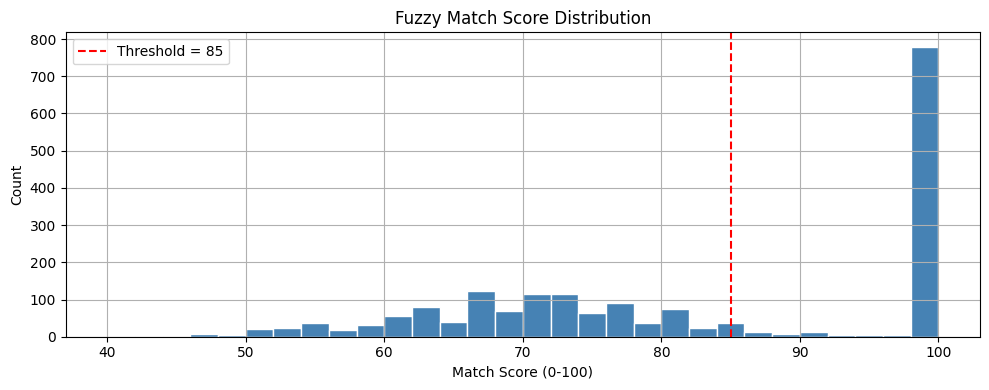


Matches with score >= 85 : 837 / 1902
Matches with score >= 80 : 961 / 1902
Matches with score >= 75 : 1140 / 1902


In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
match_df['score'].hist(bins=30, color='steelblue', edgecolor='white')
plt.title('Fuzzy Match Score Distribution')
plt.xlabel('Match Score (0-100)')
plt.ylabel('Count')
plt.axvline(x=85, color='red', linestyle='--', label='Threshold = 85')
plt.legend()
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/DrugInteraction_Project/eda_match_scores.png')
plt.show()

print()
print(f"Matches with score >= 85 : {(match_df['score'] >= 85).sum()} / {len(match_df)}")
print(f"Matches with score >= 80 : {(match_df['score'] >= 80).sum()} / {len(match_df)}")
print(f"Matches with score >= 75 : {(match_df['score'] >= 75).sum()} / {len(match_df)}")

In [16]:
# See what's NOT matching well
bad_matches = match_df[match_df['score'] < 85].sort_values('score')
print(f"Poor matches (score < 85): {len(bad_matches)}")
print()
print(bad_matches.to_string())

Poor matches (score < 85): 1065

                                                                               ddinter_drug                                                      mid_match      score
280                                                                         st. john's wort                                                     fosfestrol  40.000000
1709  influenza a virus a/california/7/2009 (h1n1)-like antigen (propiolactone inactivated)  silver nitrate+ chlorhexidine gluconate+ allantoin+ aloe vera  42.465753
1761        influenza a virus a/vietnam/1194/2004 (h5n1) antigen (formaldehyde inactivated)                                  inactivated influenza vaccine  44.444444
1687                                 vibrio cholerae cvd 103-hgr strain live antigen (live)          calcium chloride+ potassium chloride+ sodium chloride  44.859813
1697                                  human adenovirus e serotype 4 strain cl-68578 antigen                                bacillus calme

In [17]:
# Keep matches at score >= 80
good_matches = match_df[match_df['score'] >= 80].copy()
print(f"Drugs matched at threshold 80: {len(good_matches)}")

# Build a lookup dictionary: ddinter_drug -> mid_ingredient
drug_to_mid = dict(zip(good_matches['ddinter_drug'], good_matches['mid_match']))

# Preview
for k, v in list(drug_to_mid.items())[:10]:
    print(f"  {k:30s} -> {v}")

Drugs matched at threshold 80: 961
  disulfiram                     -> disulfiram
  pyrimethamine                  -> pyrimethamine
  albendazole                    -> albendazole
  ivermectin                     -> ivermectin
  mefloquine                     -> mefloquine
  praziquantel                   -> praziquantel
  quinine                        -> quinine
  thiabendazole                  -> albendazole
  tinidazole                     -> tinidazole
  chloroquine                    -> chloroquine


In [18]:
# Lowercase DDInter drug names for matching
ddinter_clean['Drug_A_lower'] = ddinter_clean['Drug_A'].str.strip().str.lower()
ddinter_clean['Drug_B_lower'] = ddinter_clean['Drug_B'].str.strip().str.lower()

# Map to MID ingredient names
ddinter_clean['mid_drug_A'] = ddinter_clean['Drug_A_lower'].map(drug_to_mid)
ddinter_clean['mid_drug_B'] = ddinter_clean['Drug_B_lower'].map(drug_to_mid)

# Check how many pairs have BOTH drugs matched
both_matched = ddinter_clean.dropna(subset=['mid_drug_A', 'mid_drug_B'])
print(f"Total DDInter pairs         : {len(ddinter_clean)}")
print(f"Pairs with both drugs in MID: {len(both_matched)}")
print(f"Match rate                  : {len(both_matched)/len(ddinter_clean)*100:.1f}%")
print()
print("Label distribution in matched pairs:")
print(both_matched['label'].value_counts())

Total DDInter pairs         : 175201
Pairs with both drugs in MID: 64876
Match rate                  : 37.0%

Label distribution in matched pairs:
label
1    48321
2    12409
0     4146
Name: count, dtype: int64


In [23]:
# Fix: strip whitespace from MID index
mid_indexed = mid_lookup.set_index('active_ingredient')
mid_indexed.index = mid_indexed.index.str.strip()

feature_cols = [
    'THERAPEUTIC_CLASS', 'ACTION_CLASS', 'CHEMICAL_CLASS',
    'HABIT_FORMING', 'alcohol_label', 'pregnancy_label',
    'kidney_label', 'liver_label'
]

# Rename MID columns with A_ prefix and merge on Drug A
mid_A = mid_indexed[feature_cols].copy()
mid_A.columns = [f'A_{c}' for c in feature_cols]
mid_A = mid_A.reset_index().rename(columns={'active_ingredient': 'mid_drug_A'})

# Rename MID columns with B_ prefix and merge on Drug B
mid_B = mid_indexed[feature_cols].copy()
mid_B.columns = [f'B_{c}' for c in feature_cols]
mid_B = mid_B.reset_index().rename(columns={'active_ingredient': 'mid_drug_B'})

# Start from both_matched
base = both_matched[['Drug_A', 'Drug_B', 'Level', 'label',
                      'mid_drug_A', 'mid_drug_B']].reset_index(drop=True)

# Merge Drug A features
final_df = base.merge(mid_A, on='mid_drug_A', how='left')

# Merge Drug B features
final_df = final_df.merge(mid_B, on='mid_drug_B', how='left')

# Drop helper columns
final_df = final_df.drop(columns=['mid_drug_A', 'mid_drug_B'])

print(f"Final dataset shape: {final_df.shape}")
print()
print(final_df.head(3).to_string())

Final dataset shape: (64876, 20)

        Drug_A      Drug_B     Level  label A_THERAPEUTIC_CLASS                 A_ACTION_CLASS             A_CHEMICAL_CLASS A_HABIT_FORMING      A_alcohol_label    A_pregnancy_label A_kidney_label A_liver_label B_THERAPEUTIC_CLASS                                                  B_ACTION_CLASS     B_CHEMICAL_CLASS B_HABIT_FORMING B_alcohol_label    B_pregnancy_label      B_kidney_label B_liver_label
0   Disulfiram    Abacavir     Minor      0           NEURO CNS            Alcohol deaddiction         Carbamate Derivative              No                 SAFE  CONSULT YOUR DOCTOR        CAUTION       CAUTION     ANTI INFECTIVES  Nucleoside/nucleotide reverse transcriptase inhibitors (NRTIs)  Nucleoside analogue              No         CAUTION  CONSULT YOUR DOCTOR  SAFE IF PRESCRIBED       CAUTION
1  Chloroquine  Paclitaxel  Moderate      1             OPHTHAL  Antimalarial- Aminoquinolines  4-Aminoquinoline derivative              No  CONSULT YOUR DOCTOR

In [24]:
print("=== Null check in final dataset ===")
print(final_df.isnull().sum())
print()

# Drop rows where any feature is missing
final_clean = final_df.dropna()
print(f"Rows before null drop : {len(final_df)}")
print(f"Rows after null drop  : {len(final_clean)}")
print()
print("=== Final label distribution ===")
print(final_clean['label'].value_counts())

# Save
final_clean.to_csv(
    '/content/drive/MyDrive/DrugInteraction_Project/final_dataset.csv',
    index=False
)
print("\nSaved: final_dataset.csv")

=== Null check in final dataset ===
Drug_A                     0
Drug_B                     0
Level                      0
label                      0
A_THERAPEUTIC_CLASS        0
A_ACTION_CLASS          5741
A_CHEMICAL_CLASS          60
A_HABIT_FORMING            0
A_alcohol_label            0
A_pregnancy_label          0
A_kidney_label             0
A_liver_label              0
B_THERAPEUTIC_CLASS        0
B_ACTION_CLASS         10641
B_CHEMICAL_CLASS         656
B_HABIT_FORMING            0
B_alcohol_label            0
B_pregnancy_label          0
B_kidney_label             0
B_liver_label              0
dtype: int64

Rows before null drop : 64876
Rows after null drop  : 49505

=== Final label distribution ===
label
1    37213
2     8946
0     3346
Name: count, dtype: int64

Saved: final_dataset.csv


In [21]:
# # Check what the MID index actually looks like
# print("MID index sample:")
# print(mid_indexed.index[:10].tolist())
# print()

# # Check what mid_drug_A values look like
# print("mid_drug_A sample from both_matched:")
# print(both_matched['mid_drug_A'].head(10).tolist())
# print()

# # Manually test one lookup
# test_drug = both_matched['mid_drug_A'].iloc[0]
# print(f"Testing lookup for: '{test_drug}'")
# print(f"Is it in index: {test_drug in mid_indexed.index}")
# print()

# # Check for whitespace issues
# print("Any leading/trailing spaces in index?")
# print(mid_indexed.index.str.strip().equals(mid_indexed.index))

MID index sample:
['haloperidol', 'bevacizumab', 'darbepoetin alfa', 'enzalutamide', 'azacitidine', 'alectinib', 'exemestane', 'amoxycillin+  clavulanic acid', 'ambroxol+ levosalbutamol+ guaifenesin', 'azithromycin']

mid_drug_A sample from both_matched:
['disulfiram', 'chloroquine', 'disulfiram', 'metronidazole', 'quinine', 'paclitaxel', 'tinidazole', 'lindane', 'acarbose', 'lidocaine']

Testing lookup for: 'disulfiram'
Is it in index: True

Any leading/trailing spaces in index?
True


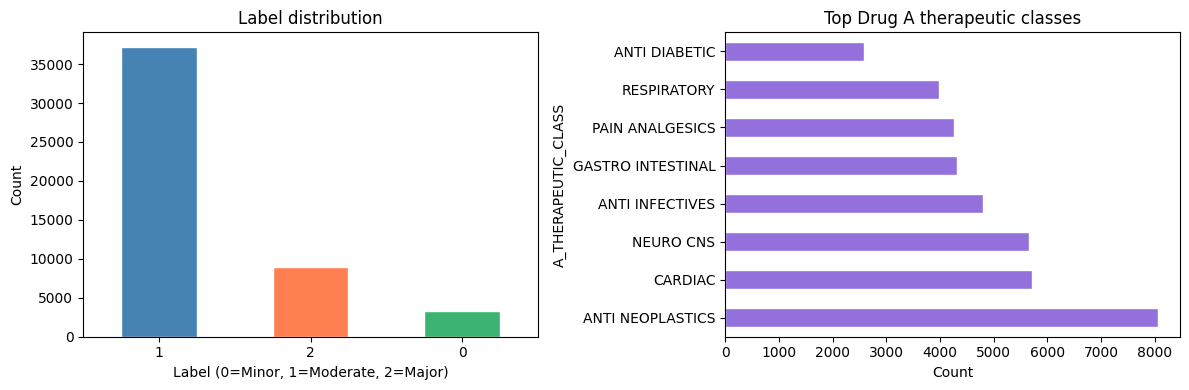

=== Dataset summary ===
Total rows     : 49505
Total features : 17
Label column   : label (0=Minor, 1=Moderate, 2=Major)

Columns in final dataset:
['Drug_A', 'Drug_B', 'Level', 'label', 'A_THERAPEUTIC_CLASS', 'A_ACTION_CLASS', 'A_CHEMICAL_CLASS', 'A_HABIT_FORMING', 'A_alcohol_label', 'A_pregnancy_label', 'A_kidney_label', 'A_liver_label', 'B_THERAPEUTIC_CLASS', 'B_ACTION_CLASS', 'B_CHEMICAL_CLASS', 'B_HABIT_FORMING', 'B_alcohol_label', 'B_pregnancy_label', 'B_kidney_label', 'B_liver_label']


In [25]:
import matplotlib.pyplot as plt

# Label distribution plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
final_clean['label'].value_counts().plot(
    kind='bar', ax=axes[0],
    color=['steelblue', 'coral', 'mediumseagreen'],
    edgecolor='white'
)
axes[0].set_title('Label distribution')
axes[0].set_xlabel('Label (0=Minor, 1=Moderate, 2=Major)')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Therapeutic class combinations
top_therapeutic = final_clean['A_THERAPEUTIC_CLASS'].value_counts().head(8)
top_therapeutic.plot(kind='barh', ax=axes[1], color='mediumpurple', edgecolor='white')
axes[1].set_title('Top Drug A therapeutic classes')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/DrugInteraction_Project/final_dataset_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print("=== Dataset summary ===")
print(f"Total rows     : {len(final_clean)}")
print(f"Total features : {final_clean.shape[1] - 3}")  # exclude Drug_A, Drug_B, Level
print(f"Label column   : label (0=Minor, 1=Moderate, 2=Major)")
print()
print("Columns in final dataset:")
print(final_clean.columns.tolist())